# Data Dictionaries Anlysis

In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy
import glob
from pathlib import Path
import os

## Paths

In [207]:
HOME = True 

if HOME:
    dict_path = "./data/"
else:
    dict_path = "/home/davidgomezortiz/medical_imaging/data_dictionaries/"

# Coruña
corunha_excel = dict_path + "coruña/2025_07_07_006_001.xlsx"

# La princesa
princesa_2025 = dict_path + "princesa/2025/"
princesa_2026 = dict_path + "princesa/2026/"

princesa_2025_ls = glob.glob(princesa_2025+"*.xlsx")
princesa_2026_ls = glob.glob(princesa_2026+"*.xlsx")

## Corunha

In [208]:
corunha_df = pd.read_excel(corunha_excel, sheet_name="datos")
corunha_df['source_file'] = os.path.basename(corunha_excel)

corunha_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   eco_id           50 non-null     str    
 1   evaluador_id     50 non-null     int64  
 2   ecografo         50 non-null     str    
 3   tipo_imagen      50 non-null     str    
 4   joint type       50 non-null     str    
 5   joint number     50 non-null     int64  
 6   plane            50 non-null     str    
 7   EG sinovial      48 non-null     float64
 8   PD sinovial      34 non-null     float64
 9   EG ext. común    0 non-null      float64
 10  PD ext. común    0 non-null      float64
 11  EG ext. cubital  0 non-null      float64
 12  PD ext. Cubital  0 non-null      float64
 13  bone erosion     2 non-null      str    
 14  source_file      50 non-null     str    
dtypes: float64(6), int64(2), str(7)
memory usage: 6.0 KB


/home/guille/Personal/CTB/msk-ultrasound-cv/venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [209]:
corunha_df.describe()

,evaluador_id,joint number,EG sinovial,PD sinovial,EG ext. común,PD ext. común,EG ext. cubital,PD ext. Cubital
count,50.0,50.0,48.000000,34.000000,0.0,0.0,0.0,0.0
mean,1.0,2.0,0.416667,0.205882,NaN,NaN,NaN,NaN
std,0.0,0.0,0.895220,0.686644,NaN,NaN,NaN,NaN
min,1.0,2.0,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1.0,2.0,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,1.0,2.0,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,1.0,2.0,0.000000,0.000000,NaN,NaN,NaN,NaN
max,1.0,2.0,3.000000,3.000000,NaN,NaN,NaN,NaN


## La Princesa

In [210]:
def load_clean(file):
    # Only read the first 1000 rows to avoid the million ghost rows
    df = pd.read_excel(file, sheet_name="datos", nrows=1000)
    
    # filter real rows (Issues with 20250813_09_002.xlsx)
    df = df.dropna(subset=["eco_id"])

    df['source_file'] = os.path.basename(file)

    return df


princesa_2025_df = pd.concat(
    [load_clean(file) for file in princesa_2025_ls],
    ignore_index=True
)

princesa_2026_df = pd.concat(
    [load_clean(file) for file in princesa_2026_ls],
    ignore_index=True
)

princesa_df = pd.concat([princesa_2025_df, princesa_2026_df], ignore_index=True)
princesa_df.info()

/home/guille/Personal/CTB/msk-ultrasound-cv/venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/guille/Personal/CTB/msk-ultrasound-cv/venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/guille/Personal/CTB/msk-ultrasound-cv/venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/guille/Personal/CTB/msk-ultrasound-cv/venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/guille/Personal/CTB/msk-ultrasound-cv/venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(

<class 'pandas.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   eco_id           3323 non-null   str    
 1   evaluador_id     3323 non-null   float64
 2   ecografo         3323 non-null   str    
 3   tipo_imagen      3323 non-null   str    
 4   joint type       3323 non-null   str    
 5   joint number     2434 non-null   float64
 6   plane            3323 non-null   str    
 7   EG sinovial      2695 non-null   float64
 8   PD sinovial      1667 non-null   float64
 9   EG ext. común    373 non-null    float64
 10  PD ext. común    226 non-null    float64
 11  EG ext. cubital  244 non-null    float64
 12  PD ext. Cubital  132 non-null    float64
 13  bone erosion     2697 non-null   str    
 14  source_file      3323 non-null   str    
dtypes: float64(8), str(7)
memory usage: 389.5 KB


In [211]:
princesa_df["eco_id"].notna().sum()

np.int64(3323)

In [212]:
princesa_df.describe()

,evaluador_id,joint number,EG sinovial,PD sinovial,EG ext. común,PD ext. común,EG ext. cubital,PD ext. Cubital
count,3323.000000,2434.000000,2695.000000,1667.000000,373.000000,226.000000,244.000000,132.000000
mean,1.381583,3.032457,0.486827,0.148770,0.021448,0.026549,0.290984,0.295455
std,0.485848,1.399377,0.832988,0.503949,0.206275,0.229402,0.648963,0.717700
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000,5.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000


## Combined DF

In [213]:
df_total = pd.concat([corunha_df, princesa_df], ignore_index=True)

df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 3373 entries, 0 to 3372
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   eco_id           3373 non-null   str    
 1   evaluador_id     3373 non-null   float64
 2   ecografo         3373 non-null   str    
 3   tipo_imagen      3373 non-null   str    
 4   joint type       3373 non-null   str    
 5   joint number     2484 non-null   float64
 6   plane            3373 non-null   str    
 7   EG sinovial      2743 non-null   float64
 8   PD sinovial      1701 non-null   float64
 9   EG ext. común    373 non-null    float64
 10  PD ext. común    226 non-null    float64
 11  EG ext. cubital  244 non-null    float64
 12  PD ext. Cubital  132 non-null    float64
 13  bone erosion     2699 non-null   str    
 14  source_file      3373 non-null   str    
dtypes: float64(8), str(7)
memory usage: 395.4 KB


In [214]:
df_total.describe()

,evaluador_id,joint number,EG sinovial,PD sinovial,EG ext. común,PD ext. común,EG ext. cubital,PD ext. Cubital
count,3373.000000,2484.000000,2743.000000,1701.000000,373.000000,226.000000,244.000000,132.000000
mean,1.375926,3.011675,0.485600,0.149912,0.021448,0.026549,0.290984,0.295455
std,0.484433,1.392787,0.833993,0.508037,0.206275,0.229402,0.648963,0.717700
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000,5.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000


## Analysis

### Counts Per Group

In [215]:
# Clean column names
df_total.columns = df_total.columns.str.lower().str.replace(' ', '_').str.replace('.', '', regex=False)
# Replace 'N/A' with numpy.nan
df_total.replace('N/A', numpy.nan, inplace=True)
# Map the text values in bone_erosion to numbers (0 and 1)
# Adjust the dictionary keys if your dataset uses Spanish words or other variations!
erosion_mapping = {
    'absent': 0, 'not present': 0,
    'present': 1, 'presente': 1,
    '0': 0, '1': 1, '0.0': 0, '1.0': 1
}
# Apply numeric parsing first, then fall back to text mapping
numeric_erosion = pd.to_numeric(df_total['bone_erosion'], errors='coerce')
text_erosion = df_total['bone_erosion'].astype(str).str.lower().str.strip().map(erosion_mapping)
df_total['bone_erosion'] = numeric_erosion.combine_first(text_erosion)
# Convert score columns to numeric, coercing errors
score_columns = [
    'eg_sinovial', 'pd_sinovial', 'eg_ext_común', 'pd_ext_común', 
    'eg_ext_cubital', 'pd_ext_cubital', 'bone_erosion'
]
for col in score_columns:
    df_total[col] = pd.to_numeric(df_total[col], errors='coerce')
# Fill NaN in joint_number with 0 and convert to integer
df_total['joint_number'] = df_total['joint_number'].fillna(0).astype(int)
# Strip whitespace from string columns
df_total['joint_type'] = df_total['joint_type'].str.strip()
df_total['plane'] = df_total['plane'].str.strip()
df_total['tipo_imagen'] = df_total['tipo_imagen'].str.strip()
# Create a 'model_group' column for data segmentation
df_total['model_group'] = df_total['joint_type'].astype(str) + '_' + \
                         df_total['plane'].astype(str) + '_' + \
                         df_total['joint_number'].astype(str) + '_' + \
                         df_total['tipo_imagen'].astype(str)
# Display the counts of each model group
print("Data subgroups for modeling:")
print(df_total['model_group'].value_counts())


Data subgroups for modeling:
model_group
MCF_longitudinal_2_Power Doppler                    119
MCF_longitudinal_2_Modo B                           102
Radiocarpiana_longitudinal_0_Modo B                  95
Intercarpiana_longitudinal_0_Modo B                  95
Radiocarpiana_longitudinal_0_Power Doppler           94
Intercarpiana_longitudinal_0_Power Doppler           94
MCF_longitudinal_5_Modo B                            89
MCF_longitudinal_3_Modo B                            88
MCF_longitudinal_3_Power Doppler                     87
MCF_longitudinal_1_Modo B                            86
MCF_longitudinal_1_Power Doppler                     86
IFP_longitudinal_1_Modo B                            86
IFP_longitudinal_1_Power Doppler                     86
IFP_longitudinal_2_Modo B                            86
IFP_longitudinal_2_Power Doppler                     86
MCF_longitudinal_5_Power Doppler                     85
MCF_longitudinal_4_Modo B                            85
MCF_lon

In [220]:
df_total.describe()

,evaluador_id,joint_number,eg_sinovial,pd_sinovial,eg_ext_común,pd_ext_común,eg_ext_cubital,pd_ext_cubital,bone_erosion
count,3373.000000,3373.000000,2743.000000,1701.000000,373.000000,226.000000,244.000000,132.000000,2699.000000
mean,1.375926,2.217907,0.485600,0.149912,0.021448,0.026549,0.290984,0.295455,0.103742
std,0.484433,1.785904,0.833993,0.508037,0.206275,0.229402,0.648963,0.717700,0.304982
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000,5.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,1.000000


### Duplicated Image ID

Some ID appear duplicated because the include more than one joint.

In [235]:
# 1. Isolate all rows that share an eco_id with another row
duplicates_mask = df_total['eco_id'].duplicated(keep=False)
duplicates_df = df_total[duplicates_mask].sort_values("eco_id")

# 2. Select specific columns to easily see the articulation values side-by-side
# We include 'tipo_imagen' to ensure the duplication is anatomical and not a B-Mode/Doppler mix-up
view_columns = ['eco_id', 'joint_type', 'tipo_imagen', 'plane', 'evaluador_id']

# print("--- Sample of Duplicated Rows ---")
# print(duplicates_df[view_columns]) # Adjust .head() to see more or fewer rows

# 3. Calculate the counts
total_duplicate_rows = len(duplicates_df)
unique_duplicate_images = duplicates_df['eco_id'].nunique()

print("\n--- Summary Counts ---")
print(f"Total rows involved in duplicates: {total_duplicate_rows}")
print(f"Unique image files (eco_id) containing multiple rows: {unique_duplicate_images}")

# 4. Show the exact breakdown of the articulations within these duplicates
print("\n--- Articulation (Joint Type) Breakdown ---")
print(duplicates_df['joint_type'].value_counts())


--- Summary Counts ---
Total rows involved in duplicates: 378
Unique image files (eco_id) containing multiple rows: 189

--- Articulation (Joint Type) Breakdown ---
joint_type
Intercarpiana    189
Radiocarpiana    189
Name: count, dtype: int64


### Inconsistencies With Prediction Features

Some Excels show issues when it comes to following the rules stated in the data dictiony's legend. Specifically, the anotations made by evaluator 1.

In [234]:
# 1. Define the complete feature groups based on the clinical legend
eg_features = ['eg_sinovial', 'eg_ext_común', 'eg_ext_cubital', 'bone_erosion']
pd_features = ['pd_sinovial', 'pd_ext_común', 'pd_ext_cubital']

# 2. Identify the image modes
is_doppler = df_total['tipo_imagen'].str.contains('Doppler', case=False, na=False)
is_bmode = df_total['tipo_imagen'].str.contains('Modo B', case=False, na=False)

# 3. Identify ANY presence of data in the forbidden columns using .any(axis=1)
# This checks if any of the columns in the list have a non-null value for that row
has_eg_values = df_total[eg_features].notnull().any(axis=1)
has_pd_values = df_total[pd_features].notnull().any(axis=1)

# Combined masks for all violations
doppler_violations_mask = is_doppler & has_eg_values
bmode_violations_mask = is_bmode & has_pd_values
total_violations_mask = doppler_violations_mask | bmode_violations_mask

protocol_violation = df_total[total_violations_mask]

if not protocol_violation.empty:
    print(f"⚠️ Warning: {len(protocol_violation)} total rows violate the B-Mode/Doppler exclusivity rule.\n")

# 4. Separate Hard vs Soft Violations
# Hard = At least one forbidden feature is > 0
hard_doppler_mask = is_doppler & df_total[eg_features].gt(0).any(axis=1)
hard_bmode_mask = is_bmode & df_total[pd_features].gt(0).any(axis=1)

hard_violations_mask = hard_doppler_mask | hard_bmode_mask
hard_violations = df_total[hard_violations_mask]

# Soft = It is a violation, but all the entered values were 0
soft_violations_mask = total_violations_mask & ~hard_violations_mask
soft_violations = df_total[soft_violations_mask]

# 5. Print the complete summary
print(f"Total violations: {len(protocol_violation)}")
print(f"Soft violations (All values are 0): {len(soft_violations)}")
print(f"Hard violations (At least one value > 0): {len(hard_violations)}\n")

print("--- Breakdown by Direction ---")
print(f"Doppler images with B-Mode scores: {doppler_violations_mask.sum()} (Hard: {hard_doppler_mask.sum()})")
print(f"B-Mode images with Doppler scores: {bmode_violations_mask.sum()} (Hard: {hard_bmode_mask.sum()})")

# print("\n--- Sample of Hard Doppler Violations ---")
# print(df_total[hard_doppler_mask].head(10))

# print("\n--- Sample of Hard B-Mode Violations ---")
# print(df_total[hard_bmode_mask].head(10))

⚠️ Warning: 1075 total rows violate the B-Mode/Doppler exclusivity rule.

Total violations: 1075
Soft violations (All values are 0): 645
Hard violations (At least one value > 0): 430

--- Breakdown by Direction ---
Doppler images with B-Mode scores: 1060 (Hard: 430)
B-Mode images with Doppler scores: 15 (Hard: 0)


In [223]:
# 1. Define the complete feature groups
eg_features = ['eg_sinovial', 'eg_ext_común', 'eg_ext_cubital', 'bone_erosion']
pd_features = ['pd_sinovial', 'pd_ext_común', 'pd_ext_cubital']

# 2. Identify the image modes
is_doppler = df_total['tipo_imagen'].str.contains('Doppler', case=False, na=False)
is_bmode = df_total['tipo_imagen'].str.contains('Modo B', case=False, na=False)

# 3. Isolate the hard violations (ANY forbidden feature is > 0)
hard_doppler_mask = is_doppler & df_total[eg_features].gt(0).any(axis=1)
hard_bmode_mask = is_bmode & df_total[pd_features].gt(0).any(axis=1)

# Combine into a single DataFrame for analysis
hard_v_df = df_total[hard_doppler_mask | hard_bmode_mask]

# 4. Print the analysis
print(f"--- Analysis of {len(hard_v_df)} Hard Violations ---")
print("Evaluators with hard violations:")
print(hard_v_df['evaluador_id'].value_counts().head())

print("\nTop 5 Joint Types involved:")
print(hard_v_df['joint_type'].value_counts().head())

print("\nBreakdown by Image Type:")
print(hard_v_df['tipo_imagen'].value_counts())

--- Analysis of 430 Hard Violations ---
Evaluators with hard violations:
evaluador_id
1.0    430
Name: count, dtype: int64

Top 5 Joint Types involved:
joint_type
MCF                    127
MTF                    111
Radiocubital distal     74
IFP                     69
Radiocarpiana           32
Name: count, dtype: int64

Breakdown by Image Type:
tipo_imagen
Power Doppler    430
Name: count, dtype: int64



--- Evaluator 1.0 Hard Violations by File (Total: 430) ---
            source_file  hard_violations
   20260128_09_015.xlsx               61
   20260128_09_016.xlsx               57
   20260128_09_013.xlsx               50
   20260128_09_009.xlsx               41
   20260128_09_008.xlsx               40
   20260128_09_014.xlsx               40
   20260128_09_012.xlsx               35
   20260128_09_010.xlsx               33
   20260128_09_017.xlsx               33
   20260128_09_011.xlsx               22
2025_07_07_006_001.xlsx                9
   20260128_09_018.xlsx                9


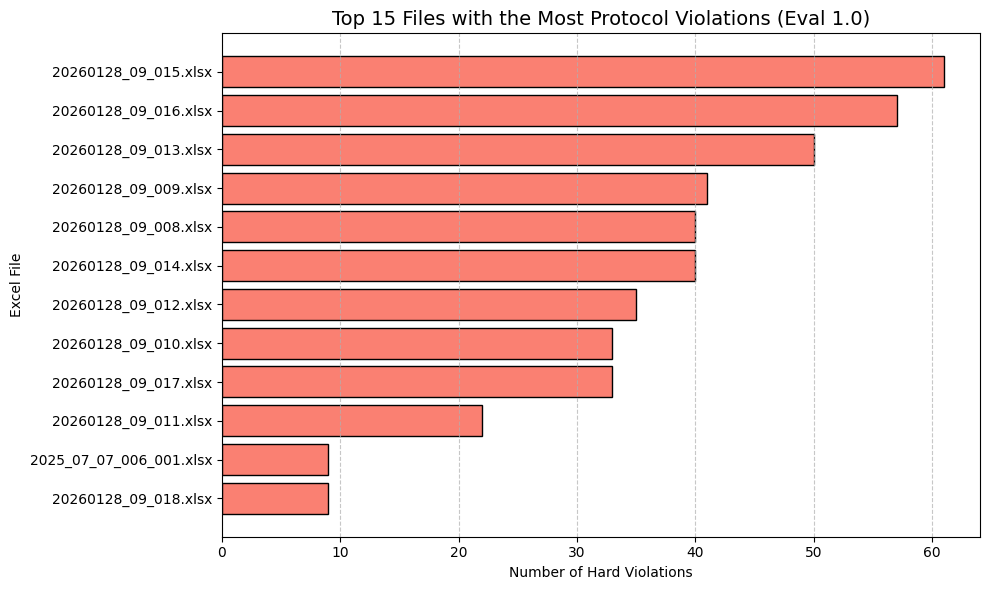

In [225]:
# Combine everything
df_tracked = df_total.copy() # Start with the original total

# Define the complete feature groups based on the clinical legend
eg_features = ['eg_sinovial', 'eg_ext_común', 'eg_ext_cubital', 'bone_erosion']
pd_features = ['pd_sinovial', 'pd_ext_común', 'pd_ext_cubital']
all_features = eg_features + pd_features


# Filter for Evaluator 1.0 Hard Violations (Two-Way Check)
is_doppler = df_tracked['tipo_imagen'].str.contains('Doppler', case=False, na=False)
is_bmode = df_tracked['tipo_imagen'].str.contains('Modo B', case=False, na=False)
is_eval_1 = df_tracked['evaluador_id'] == 1.0

# Hard violation: Any forbidden feature is > 0
hard_doppler_mask = is_doppler & df_tracked[eg_features].gt(0).any(axis=1)
hard_bmode_mask = is_bmode & df_tracked[pd_features].gt(0).any(axis=1)

is_hard_violation = hard_doppler_mask | hard_bmode_mask

# Apply the combined filter
eval1_violations = df_tracked[is_hard_violation & is_eval_1]

# 5. Group by file to see where the issues are concentrated
file_issues = eval1_violations.groupby('source_file').size().reset_index(name='hard_violations')
file_issues = file_issues.sort_values(by='hard_violations', ascending=False)

print(f"\n--- Evaluator 1.0 Hard Violations by File (Total: {len(eval1_violations)}) ---")
print(file_issues.to_string(index=False))

# Optional: Plot the top 15 worst offending files
if not file_issues.empty:
    top_files = file_issues.head(15)
    plt.figure(figsize=(10, 6))
    plt.barh(top_files['source_file'], top_files['hard_violations'], color='salmon', edgecolor='black')
    plt.gca().invert_yaxis()  # Put the file with the most errors at the top
    plt.title('Top 15 Files with the Most Protocol Violations (Eval 1.0)', fontsize=14)
    plt.xlabel('Number of Hard Violations')
    plt.ylabel('Excel File')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Rows with NaN in the target variable

In [227]:
# 1. Safely define ALL target features (including common spelling variations)
eg_features = ['eg_sinovial', 'bone_erosion', 'eg_ext_común', 'eg_ext_comun', 'eg_ext_cubital']
pd_features = ['pd_sinovial', 'pd_ext_común', 'pd_ext_comun', 'pd_ext_cubital']

# Keep only the columns that actually exist in your dataframe to prevent KeyErrors
eg_cols = [col for col in eg_features if col in df_total.columns]
pd_cols = [col for col in pd_features if col in df_total.columns]

# 2. Modality Masks
is_doppler = df_total['tipo_imagen'].str.contains('Doppler', case=False, na=False)
is_bmode = df_total['tipo_imagen'].str.contains('Modo B', case=False, na=False)

# 3. The Expanded Rule: Is it missing ALL of its rightful targets?
# (Uses .all(axis=1) because a Doppler missing ALL its PD targets is truly blank)
doppler_missing_pd = is_doppler & df_total[pd_cols].isna().all(axis=1)
bmode_missing_eg = is_bmode & df_total[eg_cols].isna().all(axis=1)

# 4. The Danger Zone: Missing its own targets BUT has data in ANY of the wrong columns
# (Uses .any(axis=1) because even one stray score in the wrong modality is dangerous)
doppler_wrong_col = doppler_missing_pd & df_total[eg_cols].notna().any(axis=1)
bmode_wrong_col = bmode_missing_eg & df_total[pd_cols].notna().any(axis=1)

print("=" * 60)
print("EXPANDED MISSING TARGET ANALYSIS")
print("=" * 60)
print(f"Doppler images missing ALL Doppler scores: {doppler_missing_pd.sum()}")
print(f" ↳ Of those, how many have ANY B-Mode score? {doppler_wrong_col.sum()} (Danger: Wrong Column / Drag-down)")
print("-" * 60)
print(f"B-Mode images missing ALL B-Mode scores: {bmode_missing_eg.sum()}")
print(f" ↳ Of those, how many have ANY Doppler score? {bmode_wrong_col.sum()} (Danger: Wrong Column / Drag-down)")
print("=" * 60)

# View the actual broken rows with their full context
if doppler_wrong_col.sum() > 0 or bmode_wrong_col.sum() > 0:
    print("\nSample of images with data explicitly in the wrong column:")
    
    # Combine both types of danger rows
    danger_rows = df_total[doppler_wrong_col | bmode_wrong_col]
    
    # Display the ID, Mode, and ALL relevant columns to see the exact spillover
    cols_to_show = ['eco_id', 'tipo_imagen', 'joint_type'] + eg_cols + pd_cols
    display(danger_rows[cols_to_show].head(15))

EXPANDED MISSING TARGET ANALYSIS
Doppler images missing ALL Doppler scores: 0
 ↳ Of those, how many have ANY B-Mode score? 0 (Danger: Wrong Column / Drag-down)
------------------------------------------------------------
B-Mode images missing ALL B-Mode scores: 0
 ↳ Of those, how many have ANY Doppler score? 0 (Danger: Wrong Column / Drag-down)


### Missing joint number

In [229]:
target_joints = ["MCF", "IFP", "MTF"]
missing_joint_number_count = (
    df_total[df_total["joint_type"].isin(target_joints) & (df_total["joint_number"] == 0)]
    .groupby("joint_type")
    .size()
    .rename("missing_count")
    .sort_index()
)
print(f"Rows with missing joint_number for {target_joints}: {missing_joint_number_count}")

Rows with missing joint_number for ['MCF', 'IFP', 'MTF']: joint_type
IFP     68
MCF    102
MTF     34
Name: missing_count, dtype: int64


## Export to Excel

In [231]:
# Export the cleaned and combined DataFrame to a new Excel file where each page contains a different model group
output_path = dict_path + "combined_data_dictionary.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for model_group, group_df in df_total.groupby('model_group'):
        group_df.to_excel(writer, sheet_name=model_group[:31], index=False)

### Export Labels CSVs
Export the cleaned dataframe to artifacts for modeling.

In [233]:
df_export = df_total.copy()

df_export = df_export[df_export['eco_id'].notna()]
df_export['eco_id'] = df_export['eco_id'].astype(str).str.strip()
df_export = df_export[df_export['eco_id'].str.lower() != 'nan']

# Write labels.csv
output_dir = Path('artifacts')
output_dir.mkdir(parents=True, exist_ok=True)
labels_path = output_dir / 'labels.csv'
df_export.to_csv(labels_path, index=False)

# Write labels_with_splits.csv (simple GroupKFold by eco_id)
df_splits = df_export.copy()
df_splits['split'] = 'train'
groups = df_splits['eco_id'].astype(str).values
strat_col = 'eg_sinovial' if 'eg_sinovial' in df_splits.columns else None
if strat_col:
    strat_key = df_splits[strat_col].fillna(-1).astype(int).astype(str).values
else:
    strat_key = numpy.zeros(len(df_splits))

from sklearn.model_selection import StratifiedGroupKFold
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fold_assign = numpy.full(len(df_splits), -1)
for fold_idx, (_, val_idx) in enumerate(splitter.split(numpy.zeros(len(df_splits)), strat_key, groups)):
    fold_assign[val_idx] = fold_idx
df_splits['split'] = fold_assign.astype(str)

labels_splits_path = output_dir / 'labels_with_splits.csv'
df_splits.to_csv(labels_splits_path, index=False)

print(f'Wrote {labels_path}')
print(f'Wrote {labels_splits_path}')



Wrote artifacts/labels.csv
Wrote artifacts/labels_with_splits.csv
